In [84]:
import numpy as np
import matplotlib.pyplot as plt


In [85]:
def f_true(x):
    return 0.03 * x ** 4 - 0.4 * x ** 2 + 0.7 * np.sin(2.2 * x)

def make_poly_features(x, degree):
    x = np.asarray(x).reshape(-1, 1)
    X = np.hstack([x ** i for i in range(degree + 1)])
    return X

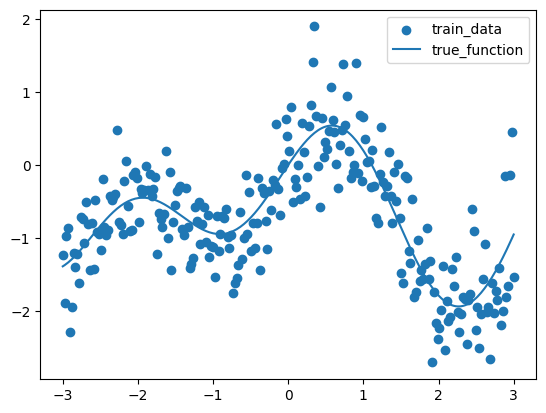

In [86]:
rng = np.random.default_rng(42)

N = 250
x = np.linspace(-3, 3, N)

sigma = 0.5
y = f_true(x) + rng.normal(0, sigma, size=x.shape)

degree = 15
X = make_poly_features(x, degree)

plt.scatter(x, y, label='train_data')
plt.plot(x, f_true(x), label='true_function')
plt.legend()
plt.show()

In [87]:
lamb = 1.0
alpha = 1.0 / (sigma ** 2)

M = X.shape[1]
posterior_cov_inv = lamb * np.eye(M) + alpha * (X.T @ X)

In [88]:
posterior_cov = np.linalg.inv(posterior_cov_inv)
mean = alpha * posterior_cov @ (X.T @ y)

In [89]:
x_new = np.linspace(-3, 3, 400)
X_new = make_poly_features(x_new, degree)

mean_pred = X_new @ mean
var_pred = 1.0 / alpha + np.sum(X_new @ posterior_cov @ X_new.T, axis=1)
std_pred = np.sqrt(var_pred)

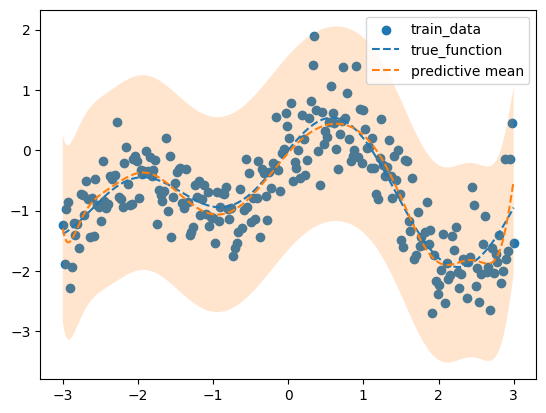

In [90]:
plt.scatter(x, y, label='train_data')
plt.plot(x_new, f_true(x_new), linestyle='--', label='true_function')
plt.plot(x_new, mean_pred, linestyle='--', label='predictive mean')

plt.fill_between(x_new, mean_pred - 2 * std_pred, mean_pred + 2 * std_pred, alpha=0.2)

plt.legend()
plt.show()

In [91]:
def log_evidence(lamb, X, y, alpha):
    n = X.shape[0]
    sigma2 = 1 / alpha
    tau2 = sigma2 / lamb

    C = sigma2 * np.eye(n) + tau2 * (X @ X.T)
    C += 1e-9 * np.eye(n)

    sign, logdet = np.linalg.slogdet(C)
    if sign <= 0:
        return -np.inf

    y = y.reshape(-1, 1)
    C_inv_y = np.linalg.solve(C, y)
    quad = (y.T @ C_inv_y).item()
    log_ev = -0.5 * (n * np.log(2 * np.pi) + logdet + quad)
    return log_ev

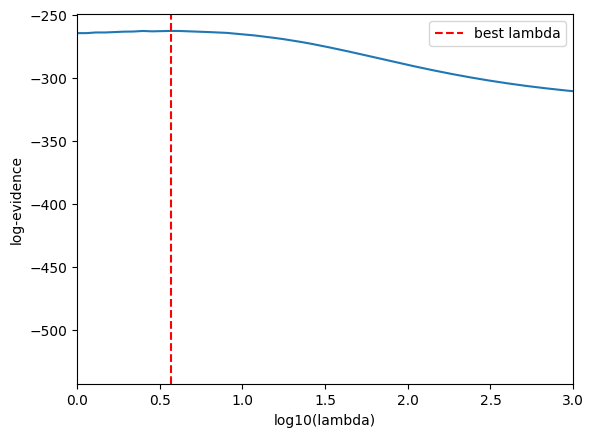

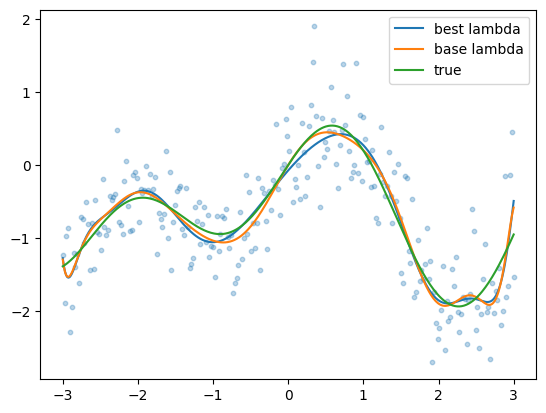

In [92]:
lambdas = np.logspace(-6, 3, 160)
log_evs = [log_evidence(lamb_, X, y, alpha) for lamb_ in lambdas]
best_idx = np.argmax(log_evs)
best_lamb = lambdas[best_idx]

plt.plot(np.log10(lambdas), log_evs)
plt.axvline(np.log10(best_lamb), color='r', linestyle='--', label='best lambda')
plt.xlabel('log10(lambda)')
plt.ylabel('log-evidence')
plt.xlim(0, 3)  # ограничиваем ось X от 0 до 3
plt.legend()
plt.show()

def get_posterior_params(X, y, lamb, alpha):
    M = X.shape[1]
    posterior_cov_inv = lamb * np.eye(M) + alpha * (X.T @ X)
    posterior_cov = np.linalg.inv(posterior_cov_inv)
    mean = alpha * posterior_cov @ (X.T @ y)
    return mean, posterior_cov

mean_best, cov_best = get_posterior_params(X, y, best_lamb, alpha)
mean_pred_best = X_new @ mean_best

mean_base, cov_base = get_posterior_params(X, y, 0.2, alpha)
mean_pred_base = X_new @ mean_base

plt.plot(x_new, mean_pred_best, label='best lambda')
plt.plot(x_new, mean_pred_base, label='base lambda')
plt.plot(x_new, f_true(x_new), label='true')
plt.scatter(x, y, s=10, alpha=0.3)
plt.legend()
plt.show()